# 유해남조류(녹조) 조기경보 — 결과 요약 (F8)

공개 데이터(국립환경과학원 조류경보제, 2015~2025)로 **다음 측정 시점(≈+7일) 유해남조류 세포수 ≥ 1,000 cells/mL(관심 단계) 초과 여부**를 예측하는 이진 조기경보.

**핵심 결과 (시간순 CV, 베이스라인 대비)**

| 방법 | PR-AUC | Recall@P0.5 |
|---|---|---|
| **LightGBM** | **0.807** | **0.905** |
| persistence(현재 상태 유지) | 0.751 | 0.835 |
| 계절 규칙 | 0.263 | 0.000 |

→ 강력한 persistence 베이스라인 대비 **의미 있는 lift**, 정밀도 50%에서 초과 이벤트의 **90%를 일주일 앞서 포착**. 학습에 없던 지점에도 잘 일반화(PR-AUC 0.785).

이 노트북은 EDA → 모델 평가 → 해석(SHAP) → 예측 예시를 재현한다. (누수 방지 §8.3: 인과적 피처 + 시간순 분할)

In [1]:
%matplotlib inline
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "features.py").exists())
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
from src import eda, modeling, validation, reporting
from src.features import assemble_dataset, feature_columns

eda.setup_style()
ds = assemble_dataset()
feats = feature_columns(ds)
print(f"데이터셋 {len(ds):,}행 × 피처 {len(feats)} | 지점 {ds['site_code'].nunique()} | "
      f"양성률 {ds['target'].mean()*100:.1f}% | 기간 {ds['date'].min().date()}~{ds['date'].max().date()}")

데이터셋 34,634행 × 피처 41 | 지점 71 | 양성률 10.2% | 기간 2014-12-29~2026-06-18


## 1. 데이터·타깃 (EDA 요약)

여름 집중 계절성 + 강한 지속성(persistence)이 모델링의 뼈대. (전체 EDA는 `eda_algae.ipynb`)

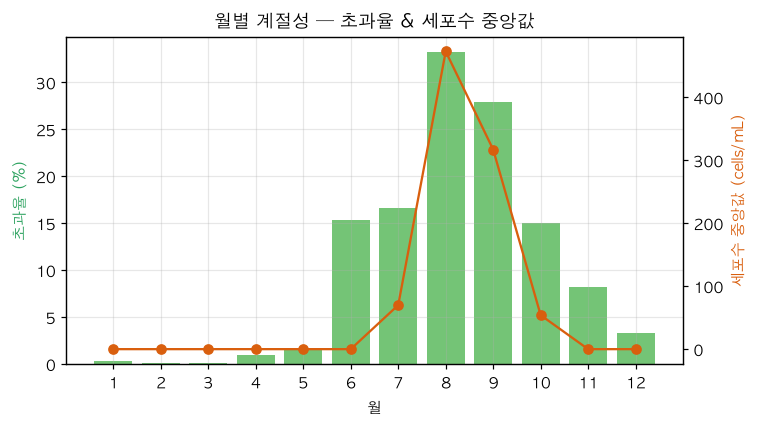

In [2]:
dfe = eda.load_clean()
eda.fig_monthly_seasonality(dfe);

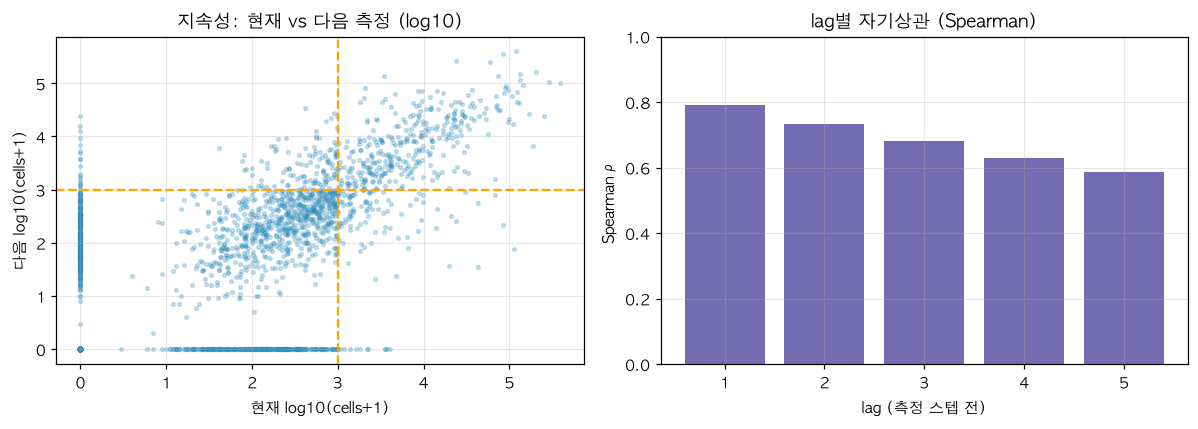

In [3]:
eda.fig_persistence_autocorr(dfe);

## 2. 모델 평가 — 시간순 CV, 베이스라인 대비

확장 윈도우 연도 분할(train = test 연도 이전 전부). 무작위 KFold 금지(§8.3).

In [4]:
X = modeling.prep_X(ds, feats)
y = ds["target"].to_numpy()
res_time, oof = modeling.run_cv(ds, X, y, validation.year_splits(ds), "time")
(res_time.groupby("method")[["pr_auc", "recall_at_p50", "roc_auc"]]
         .mean().round(3).reindex(["model", "persistence", "seasonal"]))

,pr_auc,recall_at_p50,roc_auc
method,,,
model,0.807,0.905,0.962
persistence,0.751,0.835,0.919
seasonal,0.263,0.000,0.745


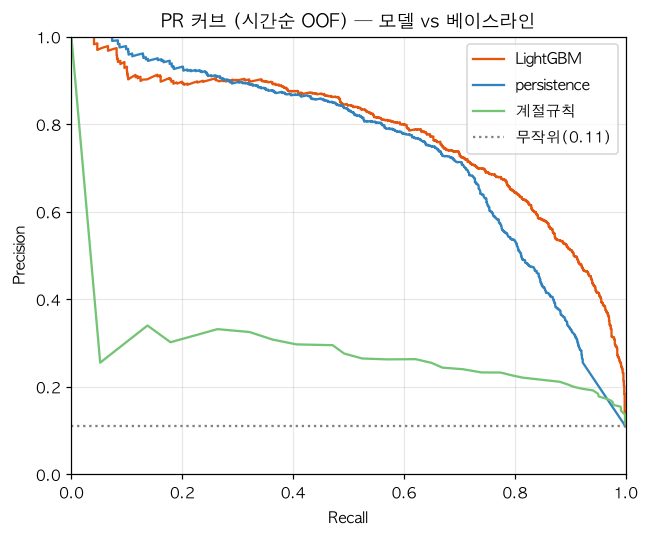

In [5]:
modeling.fig_pr_curve(oof);

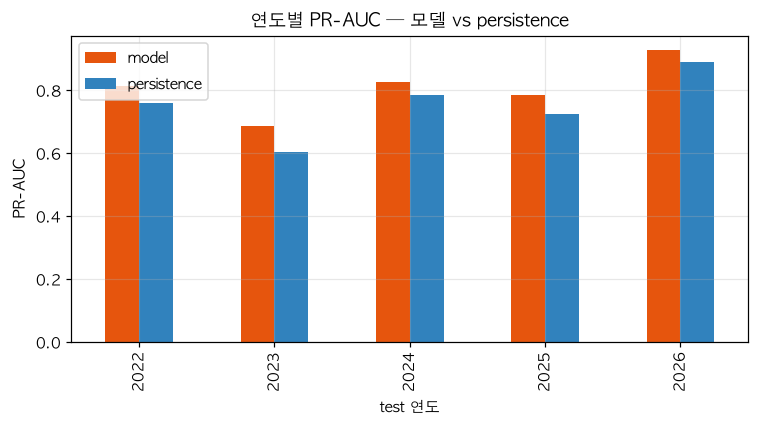

In [6]:
modeling.fig_yearly(res_time);

## 3. 해석 (SHAP) — 왜 그렇게 예측했나

LightGBM 내장 SHAP. 현재 세포수·수온↑·계절이 초과 위험을 밀어올림 — 물리적으로 타당하고 누수 지표 없음.

해석 대상: test 2026 — 203건


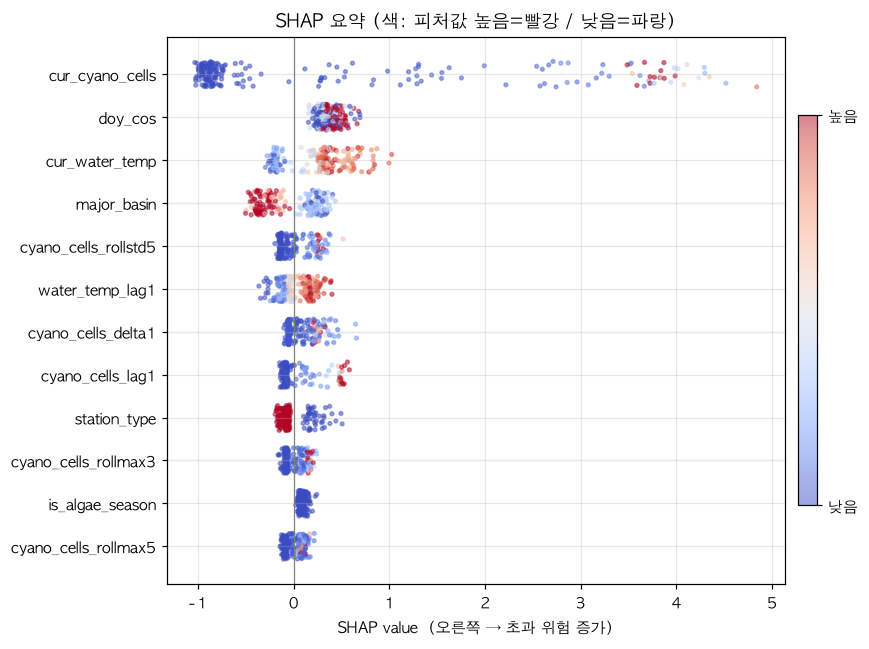

In [ ]:
model, Xc, te, test_year = reporting.fit_last_fold(ds, feats)
shap_vals = reporting.shap_contribs(model, Xc.iloc[te])
print(f"해석 대상: test {test_year} — {len(te):,}건")
reporting.fig_shap_beeswarm(shap_vals, Xc.iloc[te], feats)

## 4. 예측 위험 랭킹 (예시)

최신 연도 예측을 확률 내림차순으로 — 확률 + 실제(target) + 상위 기여 피처. 지자체가 "다음 주 위험 지점"을 우선 모니터링하는 의사결정 지원 형태.

In [8]:
reporting.risk_table(ds, model, Xc, te, feats, shap_vals, k=12)

,site_code,date,target,prob,top_features
0,2014A70,2026-06-15,1,0.964,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."
1,2020A32,2026-06-15,1,0.964,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."
2,2011G56,2026-06-18,1,0.964,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."
3,2014A25,2026-06-15,1,0.964,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."
4,2011A55,2026-06-15,1,0.964,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."
5,2020G33,2026-06-15,1,0.964,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."
6,2020G33,2026-06-08,1,0.963,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."
7,2020A32,2026-06-08,1,0.963,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."
8,2009A05,2026-06-15,1,0.963,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."
9,2011A55,2026-06-08,1,0.963,"cur_cyano_cells(+), cyano_cells_lag1(+), cur_w..."


## 결론

- 공개 데이터만으로 **재현 가능한 녹조 조기경보 파이프라인** 구축(F1~F8), 누수 방지를 코드·테스트로 강제.
- LightGBM이 강한 persistence 베이스라인을 **PR-AUC·Recall에서 상회**, 미지 지점 일반화도 양호.
- 해석(SHAP): 현재 세포수 + 최근 추세 + 수온 + 계절이 핵심 근거 — 도메인 지식과 일치.

**다음:** 기상 외생변수(ASOS lag) 결합 후 ablation으로 성능 기여 검증 → 다중분류(경보 단계)·글로벌 딥러닝 벤치마크(로드맵).